# 📋 INSTRUCTOR NOTEBOOK — Tree-Based Forecasting and Error Metrics

**Module 0 · Lesson 8 of 13 · Instructor edition**  
**Estimated class time:** 75–90 minutes  
**Source sequence:** Original Day 3  

**Prerequisite:** Lesson 7  

> **Do not distribute to students.** This edition contains solutions, teaching notes, and model answers.

## Learning objectives

By the end of this lesson, you should be able to:

- Fit random-forest and gradient-boosting forecasters to lag features.
- Compute and interpret RMSE and MAE.
- Compare learned models with naive and AR baselines.

## Setup for this lesson

This cell recreates the data and completed prerequisites from earlier lessons, so this notebook can be run in a fresh kernel.

In [ ]:
# Shared forecasting setup from the preceding lesson
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
%matplotlib inline

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'])
df.columns = ['Date', 'Passengers']
df['Log_Passengers'] = np.log(df['Passengers'])
df['Log_Diff'] = df['Log_Passengers'].diff()
series = df['Log_Diff'].dropna().values

def make_lag_matrix(series, n_lags):
    series = np.asarray(series)
    X, y = [], []
    for t in range(n_lags, len(series)):
        X.append(series[t - n_lags:t])
        y.append(series[t])
    return np.asarray(X), np.asarray(y)

N_LAGS = 12
X, y = make_lag_matrix(series, N_LAGS)
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

naive_preds = np.concatenate([[y_train[-1]], y_test[:-1]])
train_series = series[:split + N_LAGS]
ar_result = AutoReg(train_series, lags=N_LAGS).fit()
ar_preds = ar_result.predict(
    start=len(train_series),
    end=len(train_series) + len(y_test) - 1,
    dynamic=False,
)


---
## 📣 Segment 3 — Tree-Based Models (40 min)

### Introduction to Tree-Based Models

Tree-based models are a family of powerful, non-parametric supervised learning algorithms.
They require **no stationarity assumption** and can capture non-linear patterns in
lag features that AR models miss.

#### Random Forest

A **Random Forest** is an ensemble of $B$ decision trees, each trained on a bootstrap
sample of the training data and a random subset of features:

$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} T_b(\mathbf{x})$$

where $T_b$ is the $b$-th tree and $\mathbf{x}$ is the lag feature vector.
Averaging reduces variance compared to a single tree.

#### Gradient Boosted Trees

**Gradient Boosting** builds trees sequentially, where each new tree fits the
*residuals* (pseudo-errors) of the current ensemble. The update is:

$$F_{m}(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot T_m(\mathbf{x})$$

where $\eta$ is the learning rate and $T_m$ fits the negative gradient of the loss.
GBM typically achieves lower bias than Random Forest but requires careful tuning to
avoid overfitting.

### Talking Points
- **Key insight:** Both models consume the exact same lag matrix as the AR model. The
  only difference is the functional form of the model itself.
- Tree-based models don't assume linearity, so they can capture threshold effects,
  interaction effects between lags, and non-monotone relationships.
- Their main limitation for time series: they cannot extrapolate beyond the training range.
  A Random Forest predicts the mean of a leaf — it cannot predict values higher than
  any training value.

### Dividir y Confluir — Group Activity 🌊

**Assign to groups of 2–3:**
- Group A: `RandomForestRegressor(n_estimators=100, max_depth=5)`
- Group B: `RandomForestRegressor(n_estimators=200, max_depth=None)`
- Group C: `GradientBoostingRegressor(n_estimators=100, learning_rate=0.1)`
- Group D: `GradientBoostingRegressor(n_estimators=200, learning_rate=0.05)`

Each group fits their model, computes RMSE and MAE on the test set, and reports back.
Discussion: Which hyperparameters matter most? Does deeper/more trees always help?

### ⚠️ Common Mistakes
- **Feature scaling:** Tree-based models are scale-invariant — do NOT scale the lag
  matrix. Scaling is only needed for neural networks (Segments 5–6).
- **Overfitting with `max_depth=None`:** An unbounded tree will memorize training data.
  Comparing training vs test RMSE reveals this clearly.
- **Not fitting on the lag matrix:** Students sometimes try to pass the raw series to
  `RandomForestRegressor` — it doesn't know it's a time series.

In [ ]:
# ── SOLUTION: Random Forest ─────────────────────────────────────────────────
rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)  # SOLUTION
rf_model.fit(X_train, y_train)                                                     # SOLUTION
rf_preds = rf_model.predict(X_test)                                                # SOLUTION

print('Random Forest predictions (first 5):', rf_preds[:5])
print('Actual test values        (first 5):', y_test[:5])

Random Forest predictions (first 5): [-0.12761267 -0.13027947  0.12191954  0.01712475 -0.05094597]
Actual test values        (first 5): [-0.11809249 -0.14675009  0.08351063  0.0660211  -0.05129329]


In [ ]:
# ── SOLUTION: Gradient Boosting ─────────────────────────────────────────────
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)  # SOLUTION
gb_model.fit(X_train, y_train)                                                               # SOLUTION
gb_preds = gb_model.predict(X_test)                                                          # SOLUTION

print('Gradient Boosting predictions (first 5):', gb_preds[:5])
print('Actual test values            (first 5):', y_test[:5])

Gradient Boosting predictions (first 5): [-0.13876909 -0.10869124  0.11943719  0.04224436 -0.07323377]
Actual test values            (first 5): [-0.11809249 -0.14675009  0.08351063  0.0660211  -0.05129329]


---
## 📣 Segment 4 — Error Metrics & First Comparison (30 min)

### Mathematical Definitions

Let $y_t$ be the actual value at test time $t$ and $\hat{y}_t$ the model's prediction.
For a test set of size $n$:

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{t=1}^{n} (y_t - \hat{y}_t)^2}$$

$$\text{MAE}  = \frac{1}{n} \sum_{t=1}^{n} |y_t - \hat{y}_t|$$

**Key differences:**
- RMSE penalizes large errors more heavily (squaring effect). It is in the same units as
  the original series and is differentiable, making it preferred for optimization.
- MAE is more interpretable (average absolute error), more robust to outliers, and
  preferred when all errors are equally bad regardless of magnitude.

### Talking Points
- Always report **both** metrics — each tells a different story.
- On the log-differenced scale, errors will be small numbers. When communicating to
  stakeholders, transform back to the original scale for interpretability.
- The naive baseline sets the **floor**: any useful model should beat it.

### ⚠️ Common Mistakes
- **Using sklearn's `mean_squared_error` without `squared=False`:** In older sklearn
  versions, this returns MSE not RMSE. Use `np.sqrt(mean_squared_error(...))` or
  `mean_squared_error(..., squared=False)` (sklearn ≥ 0.24).
- **Comparing models across different series scales:** RMSE of a model on the raw series
  is not comparable to RMSE on the log-differenced series. Always compare on the same scale.
- **Ignoring the baseline:** Students who report a 'good' RMSE without comparing to naive
  may be reporting an unimpressive result. Push them to always contextualize.

In [ ]:
# ── SOLUTION: Error metrics function ───────────────────────────────────────
def compute_metrics(y_true, y_pred, label='Model'):
    """
    Compute and print RMSE and MAE for a set of predictions.

    Parameters
    ----------
    y_true : array-like, actual values
    y_pred : array-like, predicted values
    label  : str, model name for display

    Returns
    -------
    dict with keys 'RMSE' and 'MAE'
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))   # SOLUTION
    mae  = mean_absolute_error(y_true, y_pred)            # SOLUTION
    print(f'{label:<30}  RMSE={rmse:.5f}   MAE={mae:.5f}')
    return {'RMSE': rmse, 'MAE': mae}

results = {}
results['Naive Baseline']        = compute_metrics(y_test, naive_preds,       'Naive Baseline')
results['AR(12)']                = compute_metrics(y_test, ar_preds,   'AR(12)')
results['Random Forest']         = compute_metrics(y_test, rf_preds,          'Random Forest')
results['Gradient Boosting']     = compute_metrics(y_test, gb_preds,          'Gradient Boosting')

Naive Baseline                  RMSE=0.13377   MAE=0.11157
AR(12)                          RMSE=0.04432   MAE=0.03242
Random Forest                   RMSE=0.03929   MAE=0.03061
Gradient Boosting               RMSE=0.04205   MAE=0.03437


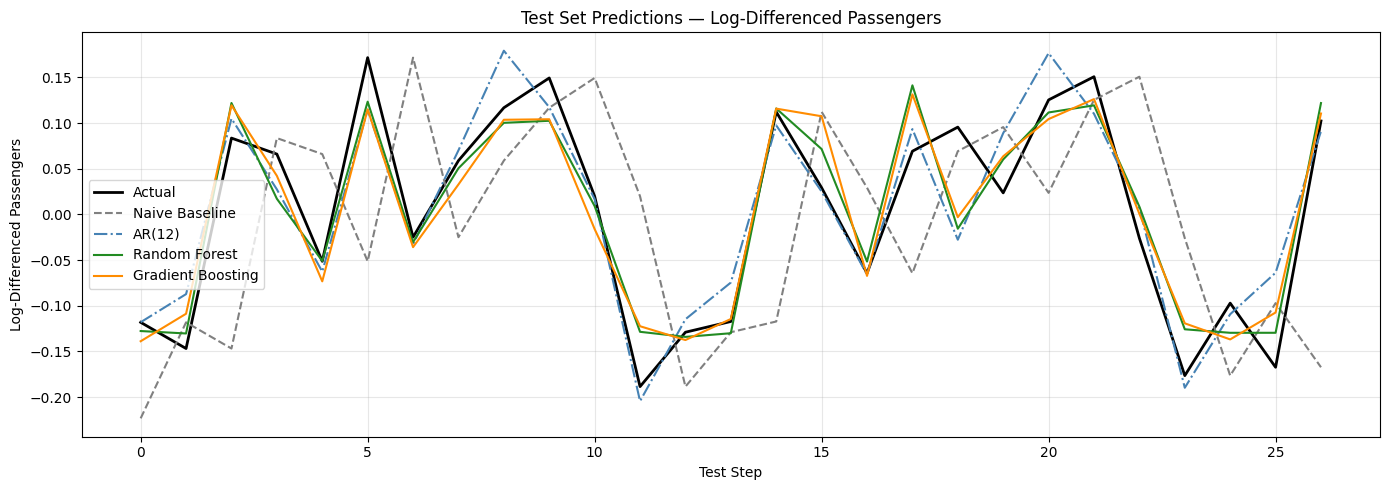

In [ ]:
# ── SOLUTION: Visualise predictions ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
test_range = np.arange(len(y_test))

ax.plot(test_range, y_test,         label='Actual',           color='black',     linewidth=2)
ax.plot(test_range, naive_preds,    label='Naive Baseline',   color='gray',      linestyle='--')
ax.plot(test_range, ar_preds,       label='AR(12)',           color='steelblue', linestyle='-.')
ax.plot(test_range, rf_preds,       label='Random Forest',    color='forestgreen')
ax.plot(test_range, gb_preds,       label='Gradient Boosting',color='darkorange')

ax.set_title('Test Set Predictions — Log-Differenced Passengers')
ax.set_xlabel('Test Step')
ax.set_ylabel('Log-Differenced Passengers')
ax.legend()
plt.tight_layout()
plt.show()

### ✅ MODEL ANSWER — Written Response 4

> **RMSE vs MAE choice:** For this dataset both metrics tell a consistent story. If a single
> large spike (e.g., a December or July outlier month) dominated the error, RMSE would
> penalize that model more heavily than MAE — making MAE the more robust summary in that case.
>
> **Beating the naive baseline** is the minimum bar. A model that matches it adds no
> forecasting value; only models with lower RMSE/MAE are candidates for deployment.
>
> **Expected pattern:** AR(12) should beat the naive baseline by capturing the seasonal lag.
> Tree-based models may match or slightly improve on AR(12), since the log-differenced
> series is close to stationary and the relationship between lags and target is roughly linear.
> On highly non-linear series, trees would show larger relative improvements.